# BATCH NORM VS NO BATCH NORM ANALYSIS

In [15]:
import numpy as np
import sys
import os
import json

import matplotlib.pyplot as plt

from pathlib import Path
sys.path.append(os.path.abspath('..'))



## CPU TRAINING WITH 15 EPOCHS ANALYSIS

In [16]:



configs_to_plot = ["plain", "bn", "skip", "resnet"]



In [17]:
def load_data(config_name):
    log_arr = []
    with open(f"./../experiments/training_{config_name}_log.json","r",encoding='utf-8') as f:
        log_arr = json.load(f)
        
    return log_arr

In [18]:
plain_training_logs = load_data("plain")
bn_training_logs = load_data("bn")
skip_training_logs = load_data("skip")
resnet_training_logs = load_data("resnet")

In [19]:
print(plain_training_logs)

[{'epoch': 1, 'train_loss': 2.3036565795825545, 'train_acc': 9.7, 'val_loss': 2.3029142929490205, 'val_acc': 9.47, 'time_taken': 52.303260349000084}, {'epoch': 2, 'train_loss': 2.3031206571372453, 'train_acc': 9.52, 'val_loss': 2.3026747703552246, 'val_acc': 9.43, 'time_taken': 47.847580260000086}, {'epoch': 3, 'train_loss': 2.30269596531133, 'train_acc': 10.45, 'val_loss': 2.3025071879101406, 'val_acc': 11.14, 'time_taken': 69.04447744599975}, {'epoch': 4, 'train_loss': 2.30239514636386, 'train_acc': 10.49, 'val_loss': 2.302372586195636, 'val_acc': 13.19, 'time_taken': 56.1248614430001}, {'epoch': 5, 'train_loss': 2.302222317191446, 'train_acc': 12.89, 'val_loss': 2.302275716878806, 'val_acc': 14.19, 'time_taken': 54.54995629999985}, {'epoch': 6, 'train_loss': 2.301928322785979, 'train_acc': 12.7, 'val_loss': 2.3021618651736313, 'val_acc': 14.0, 'time_taken': 61.23072980000006}, {'epoch': 7, 'train_loss': 2.3017419022359666, 'train_acc': 12.73, 'val_loss': 2.3020547651181555, 'val_acc

In [20]:
def build_training_arrays(arr):
    y = [x["val_loss"] for x in arr]
    x = list(range(1,len(arr) + 1 ))
    
    return y

### Loss vs Epochs plots

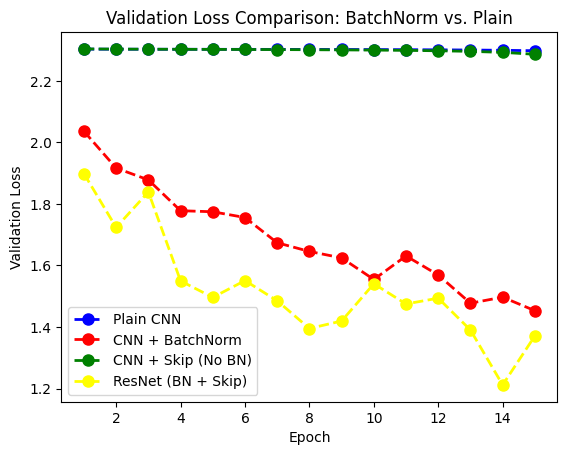

In [22]:
plain= build_training_arrays(plain_training_logs)
bn = build_training_arrays(bn_training_logs)
skip = build_training_arrays(skip_training_logs)
resnet = build_training_arrays(resnet_training_logs)

# Ensure x is defined for the 15 epochs
x = list(range(1, len(plain_training_logs) + 1))

# Plot all four models, adding the 'label' argument for the legend
plt.plot(x, plain, color='blue', linestyle='--', marker='o', linewidth=2, markersize=8, label="Plain CNN")
plt.plot(x, bn, color='red', linestyle='--', marker='o', linewidth=2, markersize=8, label="CNN + BatchNorm")
plt.plot(x, skip, color='green', linestyle='--', marker='o', linewidth=2, markersize=8, label="CNN + Skip (No BN)")
plt.plot(x, resnet, color='yellow', linestyle='--', marker='o', linewidth=2, markersize=8, label="ResNet (BN + Skip)")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison: BatchNorm vs. Plain")

# This specific command generates the key using the labels defined above
plt.legend() 

plt.show()

### Accuracy vs Epochs plot

In [29]:
def build_accuracy_arrays(arr):
    va = [x["val_acc"] for x in arr]
    ta = [x["train_acc"] for x in arr]
    return va,ta

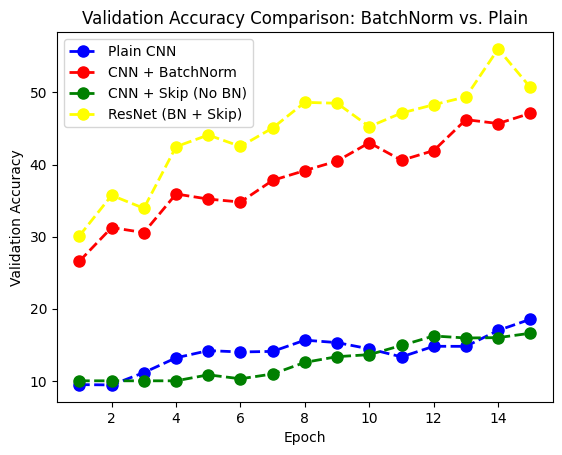

In [30]:
plain,plain_t= build_accuracy_arrays(plain_training_logs)
bn,bn_t = build_accuracy_arrays(bn_training_logs)
skip,skip_t = build_accuracy_arrays(skip_training_logs)
resnet,resnet_t = build_accuracy_arrays(resnet_training_logs)

# Ensure x is defined for the 15 epochs
x = list(range(1, len(plain_training_logs) + 1))

# Plot all four models, adding the 'label' argument for the legend
plt.plot(x, plain, color='blue', linestyle='--', marker='o', linewidth=2, markersize=8, label="Plain CNN")
plt.plot(x, bn, color='red', linestyle='--', marker='o', linewidth=2, markersize=8, label="CNN + BatchNorm")
plt.plot(x, skip, color='green', linestyle='--', marker='o', linewidth=2, markersize=8, label="CNN + Skip (No BN)")
plt.plot(x, resnet, color='yellow', linestyle='--', marker='o', linewidth=2, markersize=8, label="ResNet (BN + Skip)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison: BatchNorm vs. Plain")

# This specific command generates the key using the labels defined above
plt.legend() 

plt.show()

### Training Accuracy vs Validation Accuracy

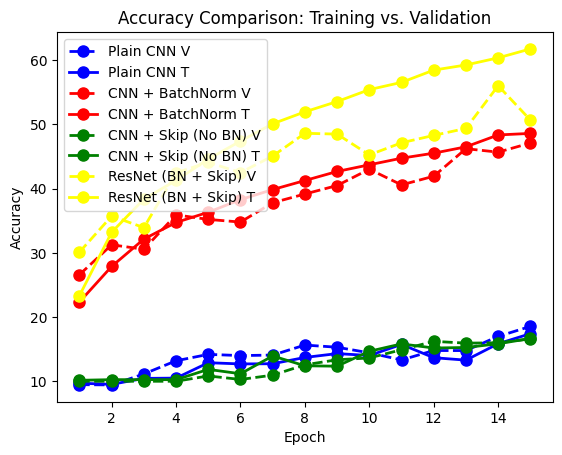

In [31]:
plain,plain_t= build_accuracy_arrays(plain_training_logs)
bn,bn_t = build_accuracy_arrays(bn_training_logs)
skip,skip_t = build_accuracy_arrays(skip_training_logs)
resnet,resnet_t = build_accuracy_arrays(resnet_training_logs)

# Ensure x is defined for the 15 epochs
x = list(range(1, len(plain_training_logs) + 1))

# Plot all four models, adding the 'label' argument for the legend
plt.plot(x, plain, color='blue', linestyle='--', marker='o', linewidth=2, markersize=8, label="Plain CNN V")
plt.plot(x, plain_t, color='blue', linestyle='-', marker='o', linewidth=2, markersize=8, label="Plain CNN T")
plt.plot(x, bn, color='red', linestyle='--', marker='o', linewidth=2, markersize=8, label="CNN + BatchNorm V")
plt.plot(x, bn_t, color='red', linestyle='-', marker='o', linewidth=2, markersize=8, label="CNN + BatchNorm T")

plt.plot(x, skip, color='green', linestyle='--', marker='o', linewidth=2, markersize=8, label="CNN + Skip (No BN) V")
plt.plot(x, skip_t, color='green', linestyle='-', marker='o', linewidth=2, markersize=8, label="CNN + Skip (No BN) T")

plt.plot(x, resnet, color='yellow', linestyle='--', marker='o', linewidth=2, markersize=8, label="ResNet (BN + Skip) V")
plt.plot(x, resnet_t, color='yellow', linestyle='-', marker='o', linewidth=2, markersize=8, label="ResNet (BN + Skip) T")


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Training vs. Validation")

# This specific command generates the key using the labels defined above
plt.legend() 

plt.show()

### Gradient Magnitude Trends

In [32]:
def build_gradient_arrays(layer,obj):
    va = [x["magnitude"] for x in obj[layer]]
  
    return va

In [33]:
def load_data(config_name):
    log_dict = dict()
    with open(f"./../experiments/{config_name}_gradient_log.json","r",encoding='utf-8') as f:
        log_dict= json.load(f)
        
    return log_dict

In [34]:
plain_training_logs = load_data("plain")
bn_training_logs = load_data("bn")
skip_training_logs = load_data("skip")
resnet_training_logs = load_data("resnet")

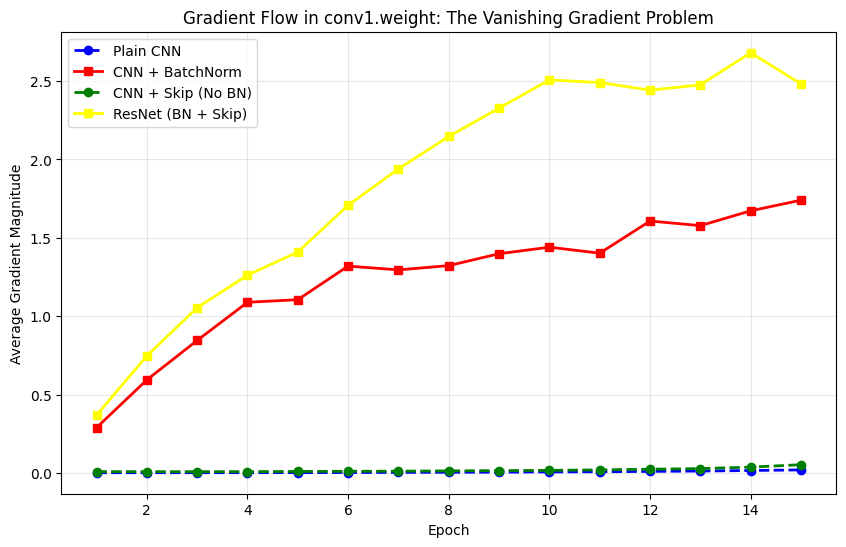

In [40]:
# 1. Load the gradient JSON data for all four models
plain_grads = load_data("plain")
bn_grads = load_data("bn")
skip_grads = load_data("skip")
resnet_grads = load_data("resnet")

# 2. Extract the magnitudes for the critical first layer
target_layer = "conv1.weight"
plain_mag = build_gradient_arrays(target_layer, plain_grads)
bn_mag = build_gradient_arrays(target_layer, bn_grads)
skip_mag = build_gradient_arrays(target_layer, skip_grads)
resnet_mag = build_gradient_arrays(target_layer, resnet_grads)

# 3. Generate the Epoch X-axis
x = list(range(1, len(plain_mag) + 1))

# 4. Plot the data
plt.figure(figsize=(10, 6)) # Make it wide enough for a report
plt.plot(x, plain_mag, color='blue', linestyle='--', marker='o', linewidth=2, label="Plain CNN")
plt.plot(x, bn_mag, color='red', linestyle='-', marker='s', linewidth=2, label="CNN + BatchNorm")
plt.plot(x, skip_mag, color='green', linestyle='--', marker='o', linewidth=2, label="CNN + Skip (No BN)")
plt.plot(x, resnet_mag, color='yellow', linestyle='-', marker='s', linewidth=2, label="ResNet (BN + Skip)")

plt.xlabel("Epoch")
plt.ylabel("Average Gradient Magnitude")
plt.title(f"Gradient Flow in {target_layer}: The Vanishing Gradient Problem")
plt.legend()
plt.grid(True, alpha=0.3) # Adds a light grid for readability
plt.show()